In [ ]:
from sklearn.datasets import make_classification
import numpy
import matplotlib.pyplot as plt

X, y = make_classification(
    n_samples = 2000, n_features = 2, n_redundant = 0,
    n_clusters_per_class = 1, weights = [0.97, 0.03], flip_y = 0,
    random_state = 42
)

print('Normal Data:', (y == 0).sum())
print('Abnormal Data', (y == 1).sum())

Normal Data: 1940
Abnormal Data 60


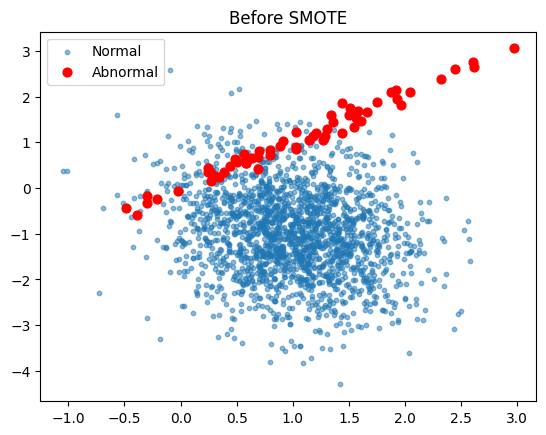

In [ ]:
plt.scatter(X[y == 0, 0], X[y == 0, 1], s = 10, label = 'Normal', alpha = 0.5)
plt.scatter(X[y == 1, 0], X[y == 1, 1], s = 40, label = 'Abnormal',
            color = 'red')
plt.legend()
plt.title('Before SMOTE')
plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state = 42)

X_res, y_res = smote.fit_resample(X, y)

print('After SMOTE normal data', (y_res == 0).sum())
print('After SMOTE abnormal data', (y_res == 1).sum())

After SMOTE normal data 1940
After SMOTE abnormal data 1940


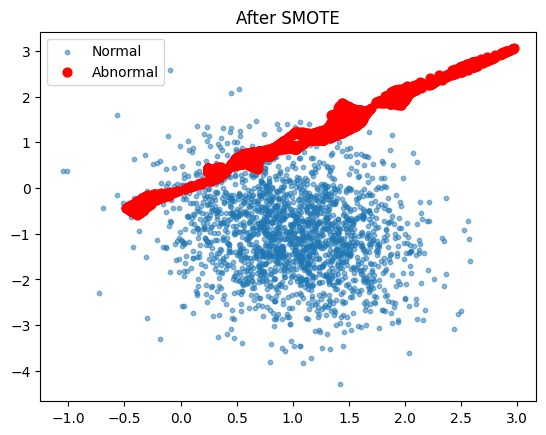

In [ ]:
plt.scatter(X_res[y_res == 0, 0], X_res[y_res == 0, 1], s = 10,
            label = 'Normal', alpha = 0.5)
plt.scatter(X_res[y_res == 1, 0], X_res[y_res == 1, 1], s = 40,
            label = 'Abnormal',  color = 'red')
plt.legend()
plt.title('After SMOTE')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)

log_reg = LogisticRegression()
model_1 = log_reg.fit(X_train, y_train)
pred_1 = model_1.predict(X_test)
print(classification_report(y_test, pred_1))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       388
           1       1.00      0.33      0.50        12

    accuracy                           0.98       400
   macro avg       0.99      0.67      0.74       400
weighted avg       0.98      0.98      0.98       400



In [ ]:
#SMOTE

X_train_sm, y_train_sm = SMOTE(random_state = 42).fit_resample(X_train, y_train)

model_smote = LogisticRegression().fit(X_train_sm, y_train_sm)
pred_smote = model_smote.predict(X_test)

print(classification_report(y_test, pred_smote))

              precision    recall  f1-score   support

           0       1.00      0.90      0.95       388
           1       0.24      1.00      0.38        12

    accuracy                           0.90       400
   macro avg       0.62      0.95      0.66       400
weighted avg       0.98      0.90      0.93       400



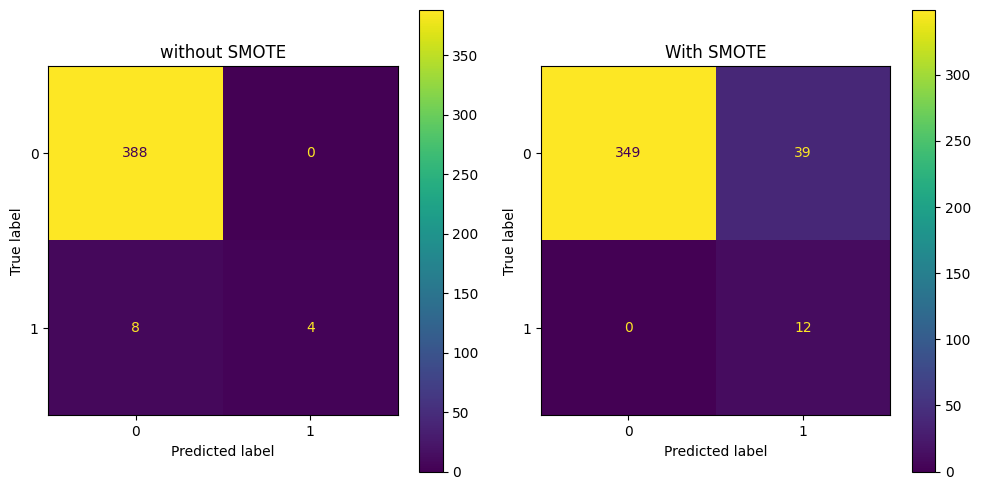

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
fig, ax = plt.subplots(1, 2, figsize = (10, 5))

ConfusionMatrixDisplay(confusion_matrix(y_test, pred_1)).plot(ax = ax[0])
ax[0].set_title('without SMOTE')

ConfusionMatrixDisplay(confusion_matrix(y_test, pred_smote)).plot(ax = ax[1])
ax[1].set_title('With SMOTE')

plt.tight_layout()
plt.show()

In [ ]:
learning_rate = 0.4
n_epochs = 20
for epoch in range(n_epochs):
    b.grad.zero_()
    w.grad.zero_()
    y_pred = X_train @ w + b
    loss = ((y_pred - y_train) ** 2).mean()
    loss.backward()
    with torch.no_grad():
        b -= learning_rate * b.grad
        w -= learning_rate * w.grad

print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {loss.item()}")